Import necessary packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import mne

Load configurations

In [3]:
from aad_trf.utils import *
config_id = 'classifier-010'
config = load_config(config_id)
config_id_trf = config['config_id_trf']
config_trf = load_config(config_id_trf)
dataset_name = config_trf['dataset']
base_path = "/Users/jusungham/HANG/aad-trf/"
path_dict = set_paths_from_config(base_path, config_trf)
model_name = config['model_name']

Load classification results of Logistic Regression

In [4]:
clf_results_by_trial_filename = f"dataset-{dataset_name}_reports-clf-results-by-trial_models-{model_name}_config-{config_id}"
results_df_lr = pd.read_csv(os.path.join(path_dict['reports'], clf_results_by_trial_filename + ".csv"))

Load classification results of SVC

In [5]:
config_id = 'classifier-011'
config = load_config(config_id)
model_name = config['model_name']
clf_results_by_trial_filename = f"dataset-{dataset_name}_reports-clf-results-by-trial_models-{model_name}_config-{config_id}"
results_df_svc = pd.read_csv(os.path.join(path_dict['reports'], clf_results_by_trial_filename + ".csv"))

In [6]:
eeg_data_filename = f"dataset-{dataset_name}_data-eeg_config-eeg-002_-epo.fif"
epochs = mne.read_epochs(os.path.join(path_dict['features'], eeg_data_filename))

Reading /Users/jusungham/HANG/aad-trf/data/features/dataset-updown-nh_data-eeg_config-eeg-002_-epo.fif ...
    Found the data of interest:
        t =    1000.00 ...    4484.38 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
3211 matching events found
No baseline correction applied
0 projection items activated


In [7]:
eeg = epochs.get_data()
# eeg = (eeg - np.mean(eeg, axis=2, keepdims=True)) / np.std(eeg, axis=2, keepdims=True)
trial_fingerprints = eeg[:,0,0]
# trial_fingerprints = np.round(trial_fingerprints, 4)

/var/folders/lx/1nly0g_s00s707fn8r7zjjch0000gn/T/ipykernel_27726/4197963171.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  eeg = epochs.get_data()


In [8]:
results_df_lr['trial_fingerprint'] = trial_fingerprints
results_df_svc['trial_fingerprint'] = trial_fingerprints

In [9]:
model_name = 'cnn'
clf_results_by_trial_filename = f"dataset-{dataset_name}_reports-clf-results-by-trial_models-{model_name}_config-004"
results_df_cnn = pd.read_csv(os.path.join(path_dict['reports'], clf_results_by_trial_filename + ".csv"))
results_df_cnn['label'] = 1 - results_df_cnn['label']
results_df_cnn['prediction'] = results_df_cnn['label'] & results_df_cnn['correct']
results_df_cnn['prediction'] = results_df_cnn['prediction'].astype(int)

Caculate prediction agreement between two models

In [10]:
prdeiction_lr = results_df_lr['prediction']
prdeiction_svc = results_df_svc['prediction']
prdeiction_cnn = results_df_cnn['prediction']
agreement = prdeiction_lr == prdeiction_svc
print(f"agreement rate: {agreement.mean():.2f}")
agreement = prdeiction_lr == prdeiction_cnn
print(f"agreement rate: {agreement.mean():.2f}")
agreement = prdeiction_svc == prdeiction_cnn
print(f"agreement rate: {agreement.mean():.2f}")
agreement_all = (prdeiction_lr == prdeiction_svc) & (prdeiction_lr == prdeiction_cnn)
print(f"agreement rate among all three models: {agreement_all.mean():.2f}")


agreement rate: 0.87
agreement rate: 0.68
agreement rate: 0.67
agreement rate among all three models: 0.61


Cohen's Kappa
> If the raters are in complete agreement then $\textstyle \kappa =1$. If there is no agreement among the raters other than what would be expected by chance, $\textstyle \kappa =0$. It is possible for the statistic to be negative, which can occur by chance if there is no relationship between the ratings of the two raters, or it may reflect a real tendency of the raters to give differing ratings.
> 
> https://en.wikipedia.org/wiki/Cohen%27s_kappa

In [11]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(prdeiction_lr, prdeiction_svc)
print(f"Cohen's Kappa: {kappa:.4f}")
kappa = cohen_kappa_score(prdeiction_lr, prdeiction_cnn)
print(f"Cohen's Kappa: {kappa:.4f}")
kappa = cohen_kappa_score(prdeiction_svc, prdeiction_cnn)
print(f"Cohen's Kappa: {kappa:.4f}")

Cohen's Kappa: 0.7364
Cohen's Kappa: 0.3563
Cohen's Kappa: 0.3299



| Model Pairs | Cohen's (Fleiss') Kappa Value |
|---|---|
| LR & SVC | 0.7364 |
| LR & CNN | 0.3563 |
| SVC & CNN | 0.3299 |
| LR & SVC & CNN | 0.4711 |


In [12]:
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

# Create a matrix of ratings
ratings = np.array([prdeiction_lr, prdeiction_svc, prdeiction_cnn]).T

# Convert predictions to counts for each rating category
rating_counts = np.zeros((ratings.shape[0], 2), dtype=int)
for i in range(ratings.shape[0]):
	unique, counts = np.unique(ratings[i], return_counts=True)
	rating_counts[i, unique] = counts

# Calculate Fleiss' Kappa
fleiss_kappa_value = fleiss_kappa(rating_counts, method='fleiss')
print(f"Fleiss' Kappa: {fleiss_kappa_value:.4f}")

Fleiss' Kappa: 0.4711


Calculate the number of common trials both models correctly classified

In [13]:
lr_correct = results_df_lr['correct']
svc_correct = results_df_svc['correct']
cnn_correct = results_df_cnn['correct'].astype(bool)
agreement_correct = lr_correct == svc_correct
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct = lr_correct == cnn_correct
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct = svc_correct == cnn_correct
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct_all = (lr_correct == svc_correct) & (lr_correct == cnn_correct)
print(f"agreement rate among all three models (correct): {agreement_correct_all.mean():.2f}")

agreement rate (correct): 0.87
agreement rate (correct): 0.70
agreement rate (correct): 0.68
agreement rate among all three models (correct): 0.63


According to the result, 87% of trials (2788) are classified correctly in both models. 7% of trials were classified correctly on logistic regression. 6% of trials were classified correctly on SVM. 

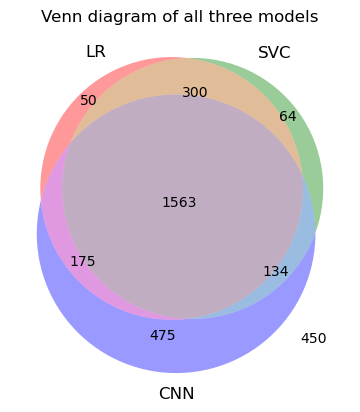

In [14]:
# plot venn diagram of all three models
only_lr_correct = lr_correct & ~svc_correct & ~cnn_correct
only_svc_correct = svc_correct & ~lr_correct & ~cnn_correct
only_cnn_correct = cnn_correct & ~lr_correct & ~svc_correct
lr_svc_correct = lr_correct & svc_correct & ~cnn_correct
lr_cnn_correct = lr_correct & ~svc_correct & cnn_correct
svc_cnn_correct = ~lr_correct & svc_correct & cnn_correct
all_correct = lr_correct & svc_correct & cnn_correct
all_incorrect = ~lr_correct & ~svc_correct & ~cnn_correct

from matplotlib_venn import venn3
plt.figure()
fig_venn = venn3(subsets=(only_lr_correct.sum(), only_svc_correct.sum(), lr_svc_correct.sum(), only_cnn_correct.sum(), 
               lr_cnn_correct.sum(), svc_cnn_correct.sum(), all_correct.sum()), 
                set_labels=('LR', 'SVC', 'CNN'))
# add text showing the number of all incorrect trials outside of the venn diagram
plt.text(0.5, -0.5, f"{all_incorrect.sum()}", horizontalalignment='center', verticalalignment='center', fontsize=10)
plt.title("Venn diagram of all three models")
plt.savefig(os.path.join(path_dict['reports'], f"dataset-{dataset_name}_reports-venn_diagram_all_three_models.png"))

In [15]:
all_correct_idx = all_correct[all_correct].index
all_incorrect_idx = all_incorrect[all_incorrect].index
all_correct_idx_sample = np.random.choice(all_correct_idx, len(all_incorrect_idx), replace=False)

In [16]:
# get index of correct trials
lr_correct_true = lr_correct[lr_correct]
correct_idx_lr = lr_correct_true.sample(n=len(results_df_lr) - sum(lr_correct), random_state=42).index
svc_correct_true = svc_correct[svc_correct]
correct_idx_svc = svc_correct_true.sample(n=len(results_df_svc) - sum(svc_correct), random_state=42).index
cnn_correct_true = cnn_correct[cnn_correct]
correct_idx_cnn = cnn_correct_true.sample(n=len(results_df_cnn) - sum(cnn_correct), random_state=42).index

In [17]:
# load AAD_dataset
from aad_trf.aad_dataset import AAD_Dataset
config_id_audio = 'audio-001'
config_id_eeg = 'eeg-002'
audio_filename = f"dataset-{dataset_name}_data-audio_config-{config_id_audio}"
audio = np.load(os.path.join(path_dict['features'], f"{audio_filename}.npy"))
eeg_filename = f"dataset-{dataset_name}_data-eeg_config-{config_id_eeg}_-epo"
epochs = mne.read_epochs(os.path.join(path_dict['features'], f"{eeg_filename}.fif"))
dataset = AAD_Dataset()
dataset.create(epochs, audio)
del audio, epochs

Reading /Users/jusungham/HANG/aad-trf/data/features/dataset-updown-nh_data-eeg_config-eeg-002_-epo.fif ...
    Found the data of interest:
        t =    1000.00 ...    4484.38 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
3211 matching events found
No baseline correction applied
0 projection items activated


/Users/jusungham/HANG/aad-trf/src/aad_trf/aad_dataset.py:48: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  self.eeg = eeg_epochs.get_data()


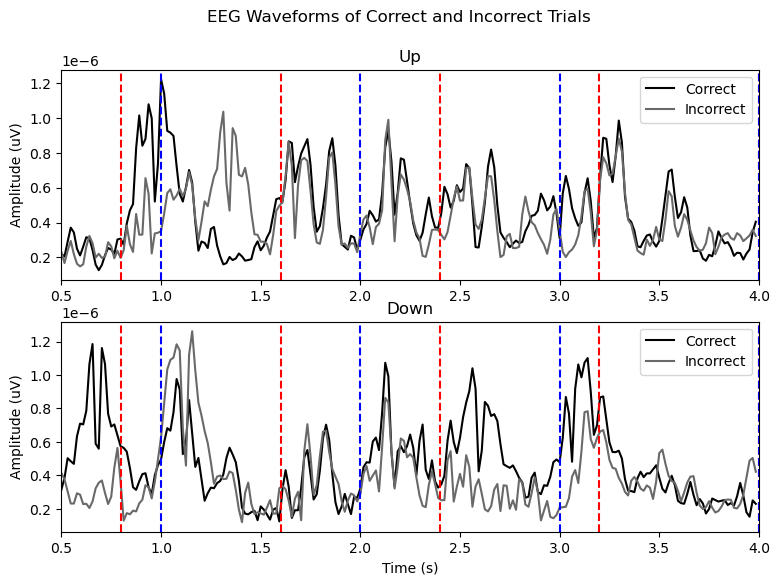

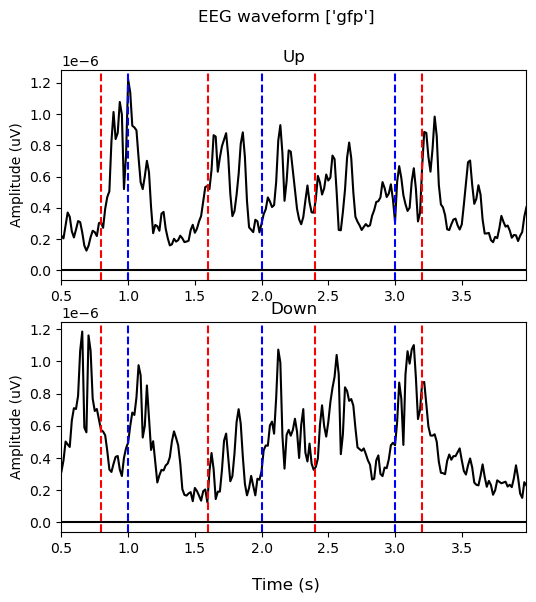

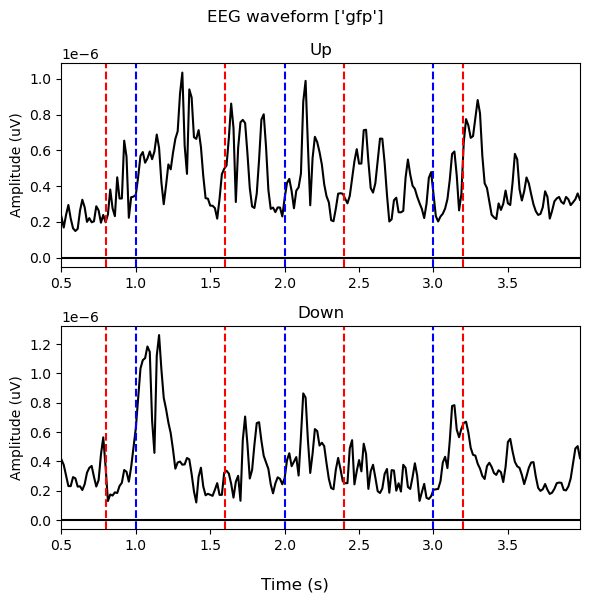

In [18]:
import matplotlib.pyplot as plt
from aad_trf.aad_plotter import plot_eeg_waveform

model_name = 'logistic-regression'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_lr], plot_channels=['gfp'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_lr], plot_channels=['gfp'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-gfp_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

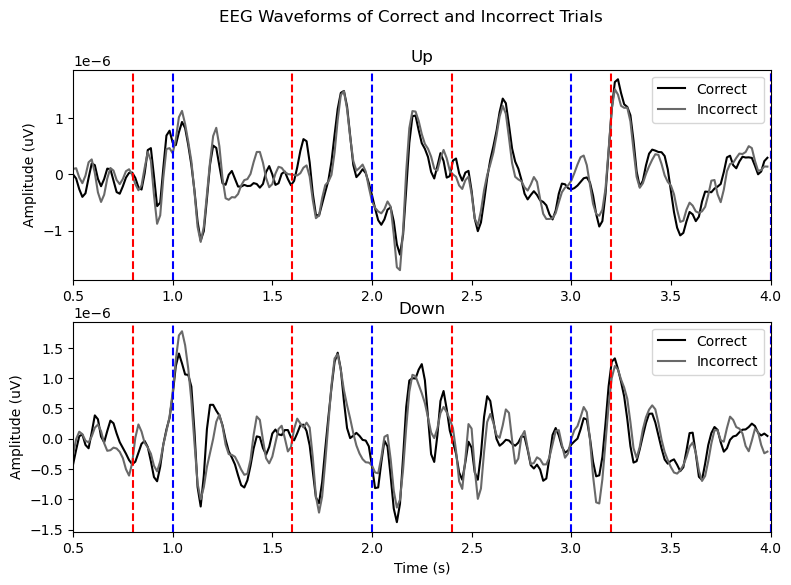

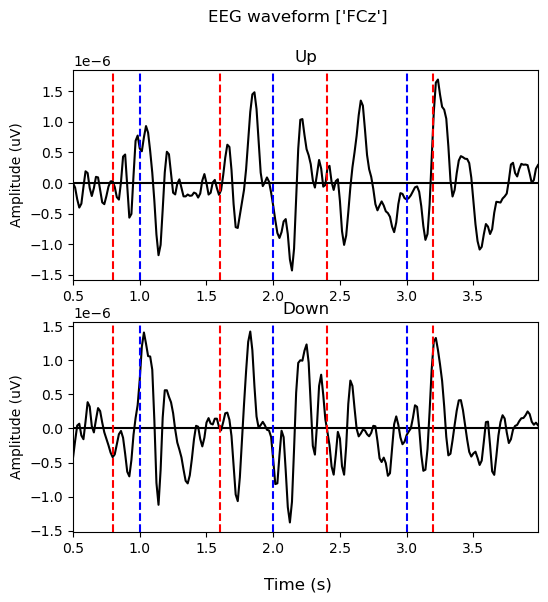

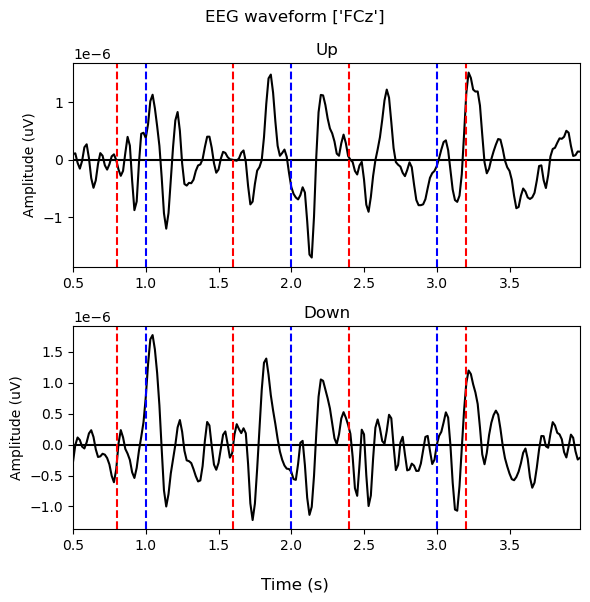

In [19]:
model_name = 'logistic-regression'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_lr], plot_channels=['FCz'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_lr], plot_channels=['FCz'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-FCz_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

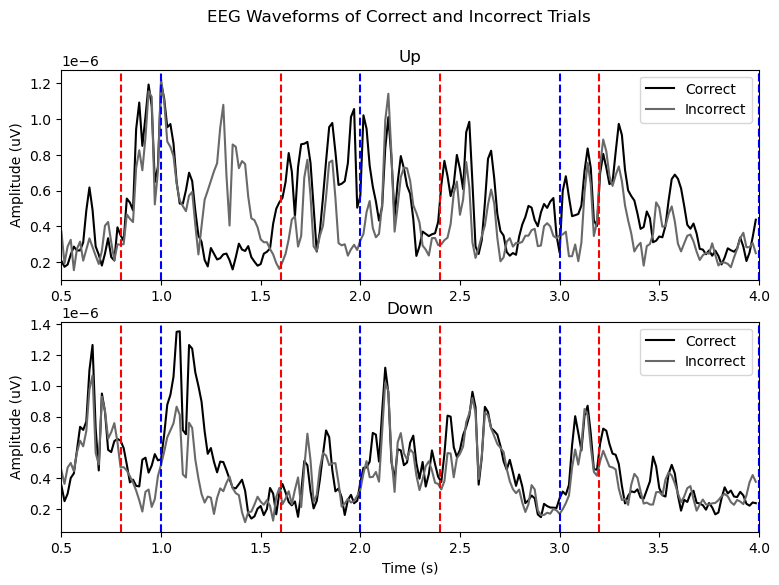

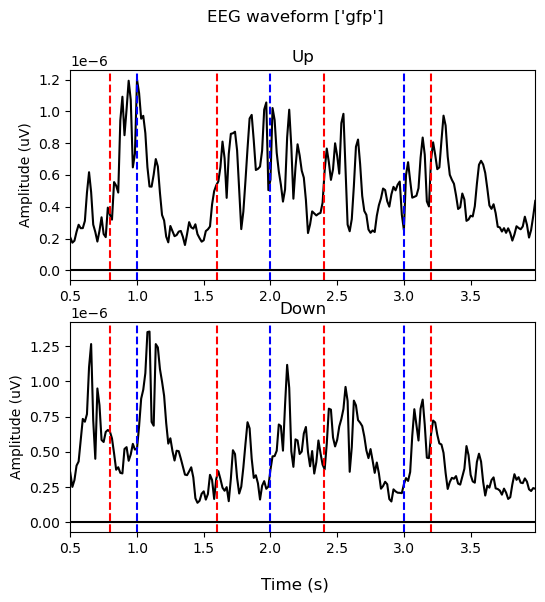

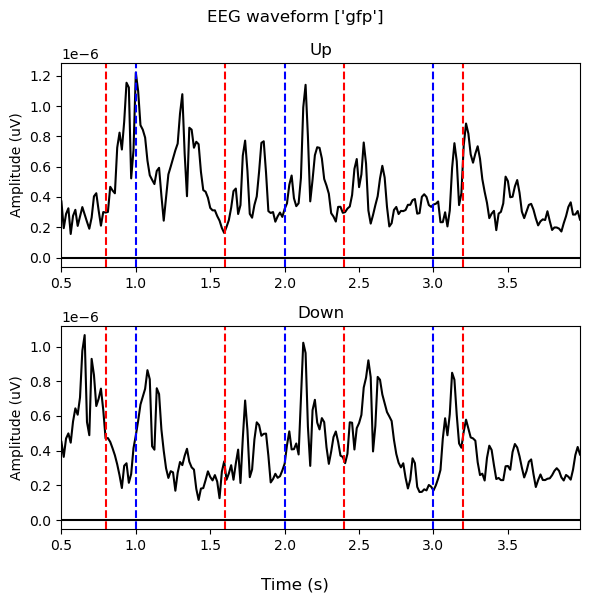

In [20]:
model_name = 'svc'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_svc], plot_channels=['gfp'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_svc], plot_channels=['gfp'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-gfp_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

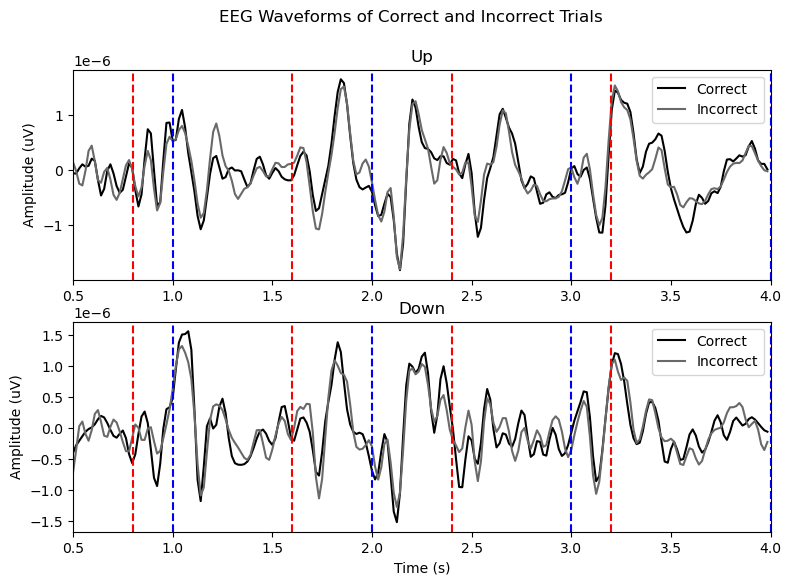

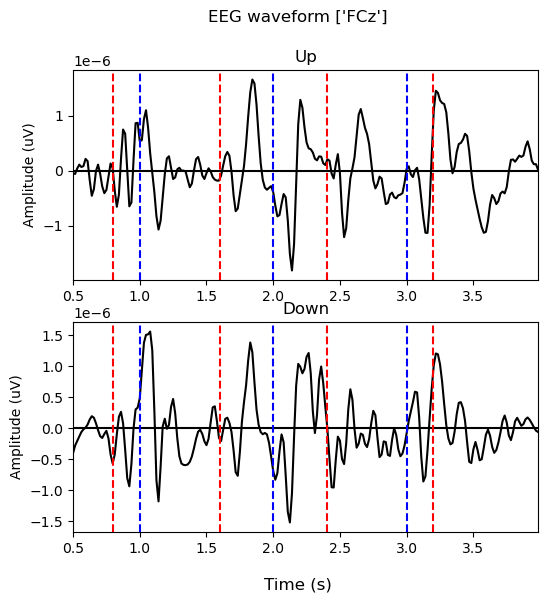

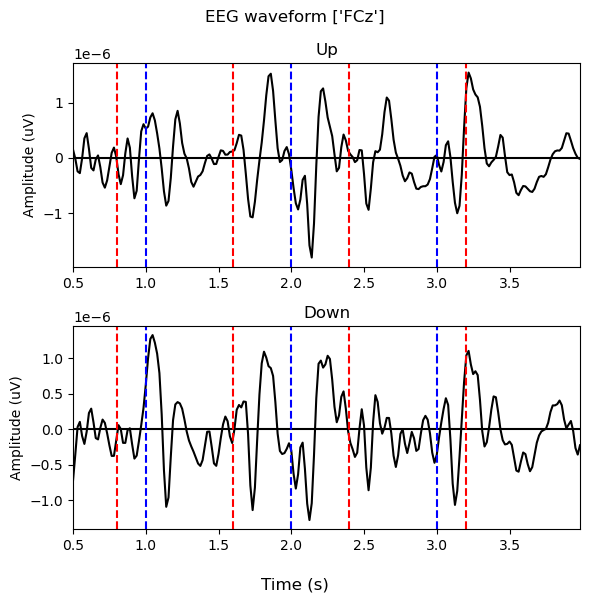

In [21]:
model_name = 'svc'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_svc], plot_channels=['FCz'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_svc], plot_channels=['FCz'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-FCz_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

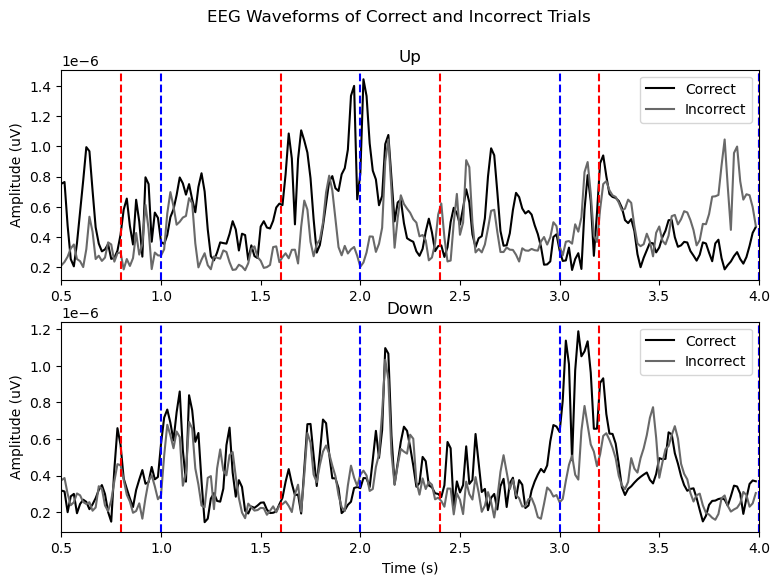

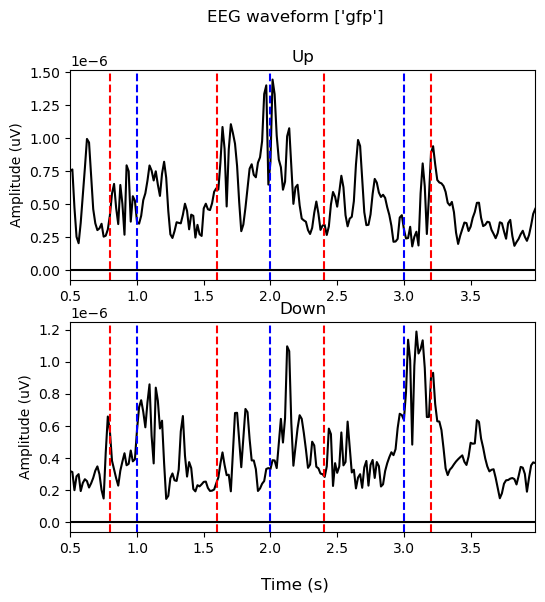

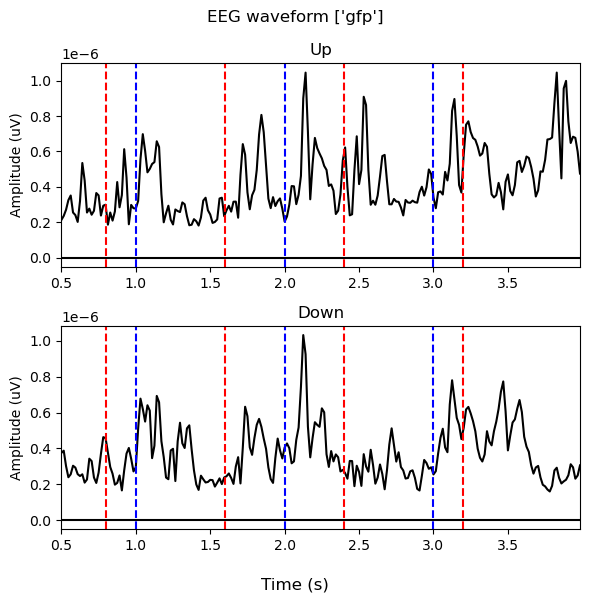

In [22]:
model_name = 'cnn'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_cnn], plot_channels=['gfp'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_cnn], plot_channels=['gfp'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-gfp_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

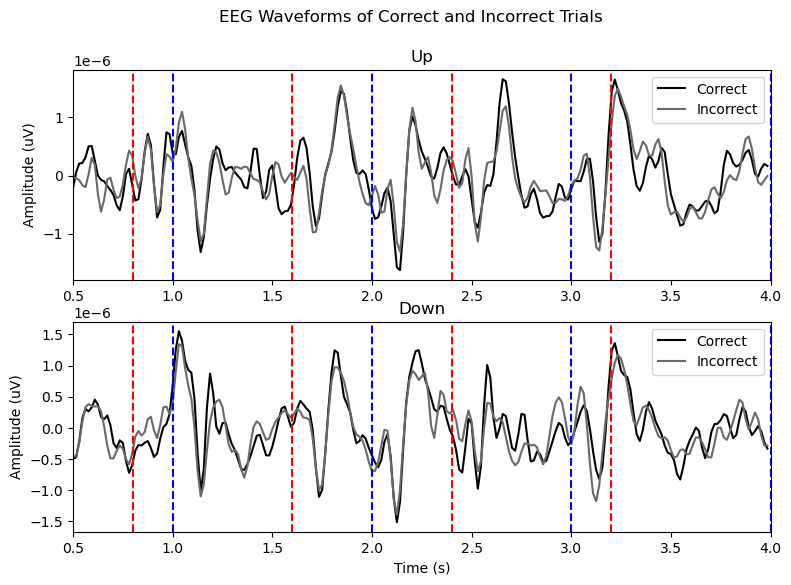

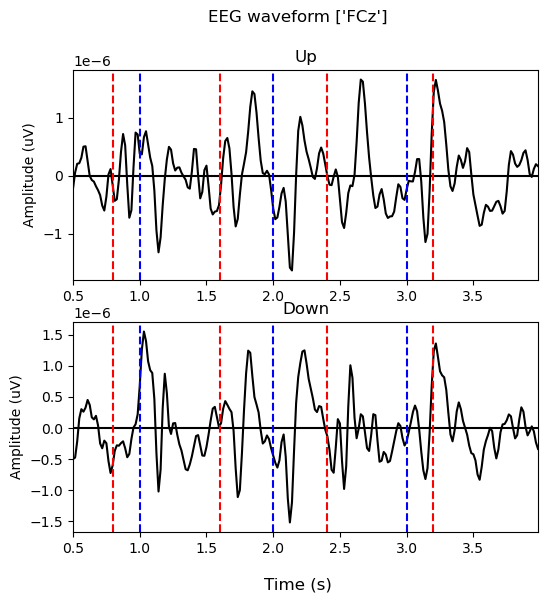

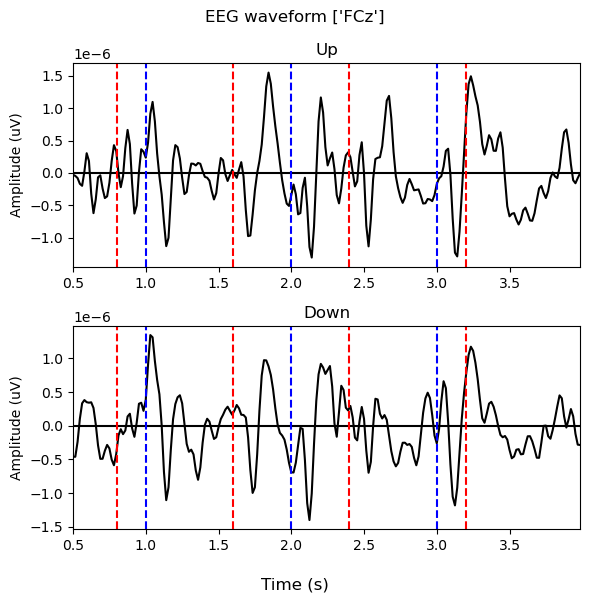

In [23]:
model_name = 'cnn'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_cnn], plot_channels=['FCz'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_cnn], plot_channels=['FCz'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-FCz_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

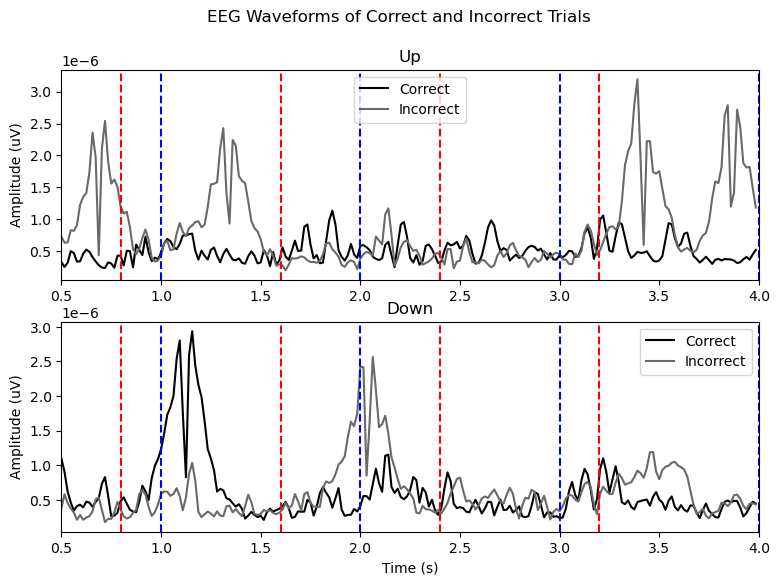

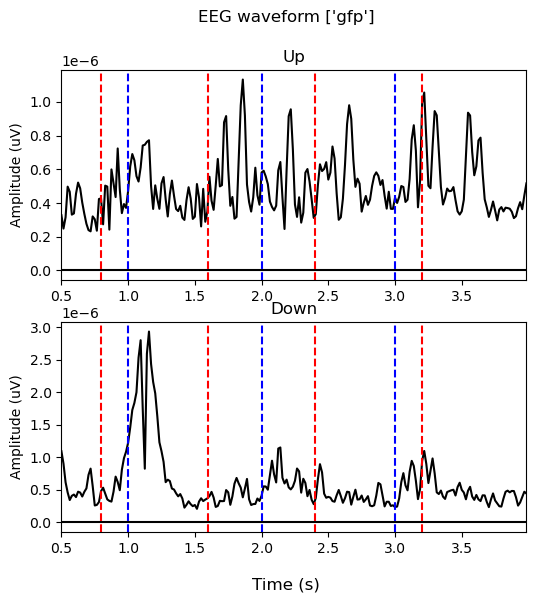

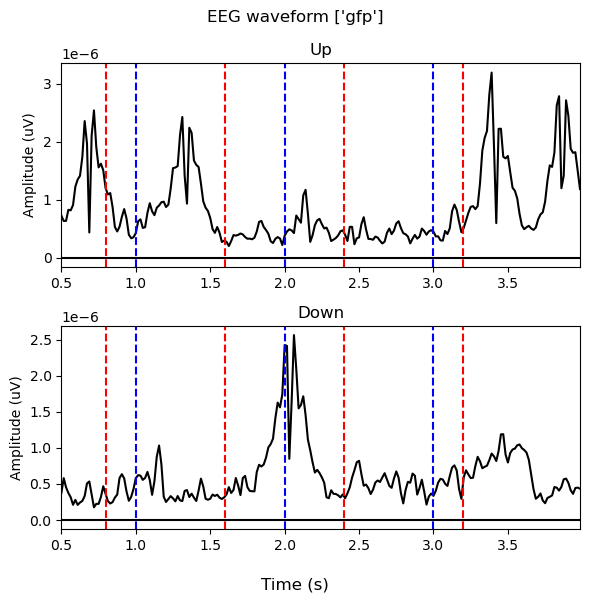

In [24]:
model_name = 'all'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[all_correct_idx_sample], plot_channels=['gfp'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[all_incorrect_idx], plot_channels=['gfp'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-gfp_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

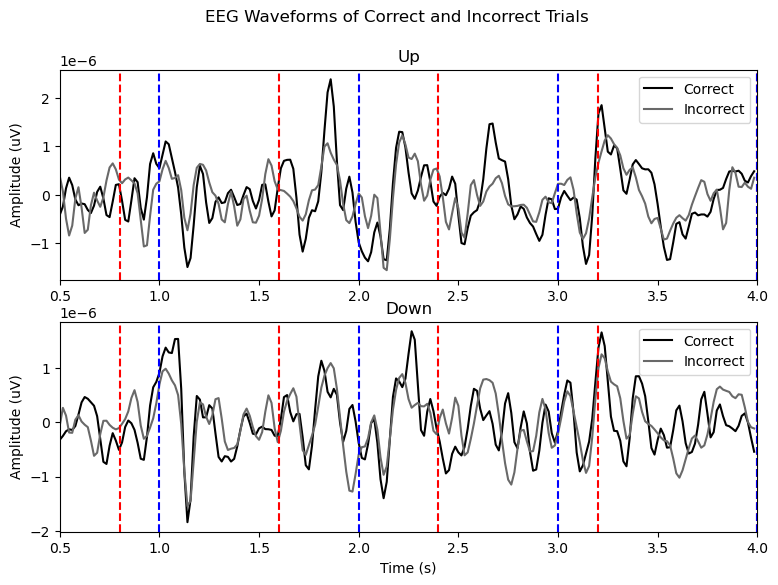

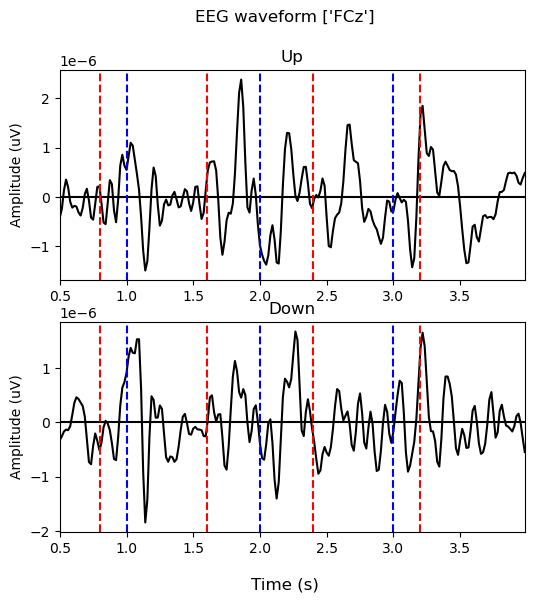

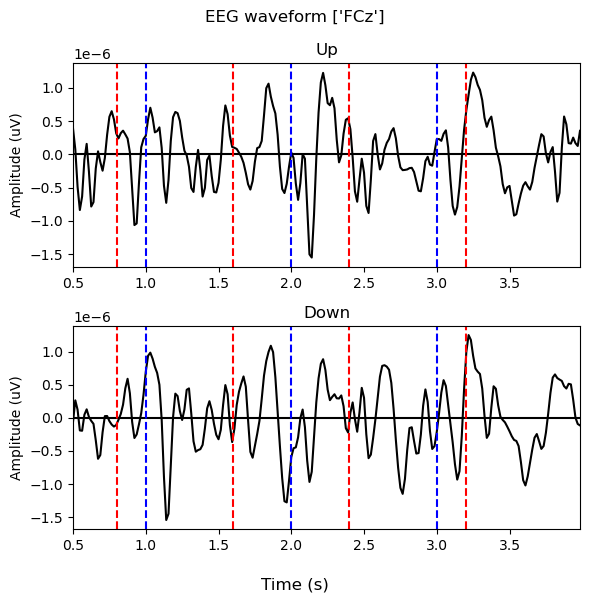

In [25]:
model_name = 'all'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[all_correct_idx_sample], plot_channels=['FCz'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[all_incorrect_idx], plot_channels=['FCz'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-FCz_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

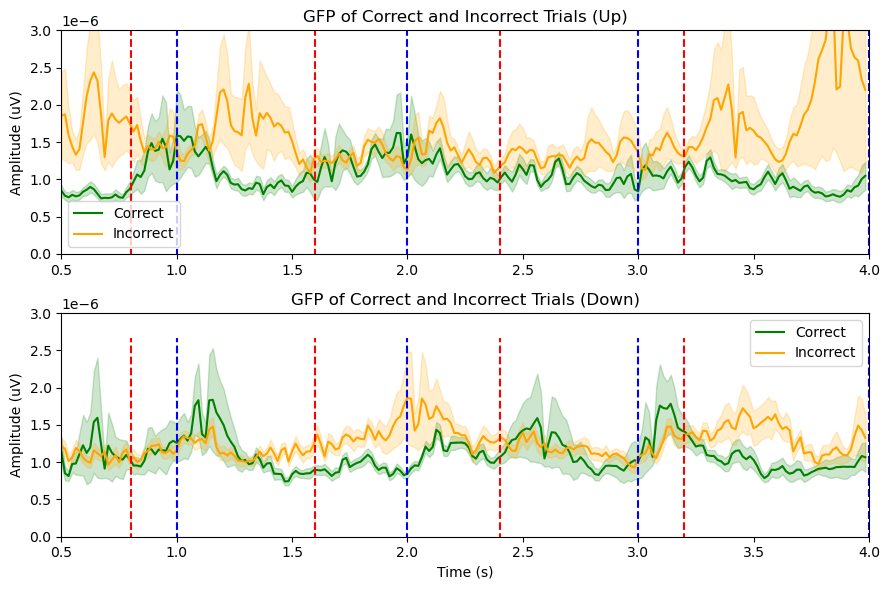

In [28]:
grouped = results_df_lr.groupby('sub_id')

# Iterate over each group
for i, (sub_id, group) in enumerate(grouped):
    correct_up_index = group.index[group['correct'] & (group['label'] == 0)].tolist()
    incorrect_up_index = group.index[~group['correct'] & (group['label'] == 0)].tolist()
    correct_down_index = group.index[group['correct'] & (group['label'] == 1)].tolist()
    incorrect_down_index = group.index[~group['correct'] & (group['label'] == 1)].tolist()

    gfp_correct_up = dataset[correct_up_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_incorrect_up = dataset[incorrect_up_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_correct_down = dataset[correct_down_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_incorrect_down = dataset[incorrect_down_index].get_eeg().mean(axis=0).std(axis=0)
    if i == 0:
        gfp_array = np.zeros((len(grouped), 4, len(gfp_correct_up)))
    gfp_array[i, 0] = gfp_correct_up
    gfp_array[i, 1] = gfp_incorrect_up
    gfp_array[i, 2] = gfp_correct_down
    gfp_array[i, 3] = gfp_incorrect_down

gfp_mean = gfp_array.mean(axis=0)
gfp_se = gfp_array.std(axis=0) / np.sqrt(len(grouped))

# Plot GFP
time = np.arange(0.5, 4, 1/64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

# Plot for 'up' label
ax1.plot(time, gfp_mean[0], color='green', label='Correct')
ax1.fill_between(time, gfp_mean[0] - gfp_se[0], gfp_mean[0] + gfp_se[0], color='green', alpha=0.2)
ax1.plot(time, gfp_mean[1], color='orange', label='Incorrect')
ax1.fill_between(time, gfp_mean[1] - gfp_se[1], gfp_mean[1] + gfp_se[1], color='orange', alpha=0.2)
ymin_up = np.min(gfp_mean[:2]) - np.max(gfp_se[:2])
ymax_up = np.max(gfp_mean[:2]) + np.max(gfp_se[:2])
ax1.vlines(np.linspace(0, 4, 6), ymin_up, ymax_up, color='r', linestyle='--')
ax1.vlines(np.linspace(0, 4, 5), ymin_up, ymax_up, color='b', linestyle='--')
ax1.set_xlim(0.5, 4)
ax1.set_ylim(0, 3e-6)
ax1.set_title('GFP of Correct and Incorrect Trials (Up)')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend()

# Plot for 'down' label
ax2.plot(time, gfp_mean[2], color='green', label='Correct')
ax2.fill_between(time, gfp_mean[2] - gfp_se[2], gfp_mean[2] + gfp_se[2], color='green', alpha=0.2)
ax2.plot(time, gfp_mean[3], color='orange', label='Incorrect')
ax2.fill_between(time, gfp_mean[3] - gfp_se[3], gfp_mean[3] + gfp_se[3], color='orange', alpha=0.2)
ymin_down = np.min(gfp_mean[2:]) - np.max(gfp_se[2:])
ymax_down = np.max(gfp_mean[2:]) + np.max(gfp_se[2:])
ax2.vlines(np.linspace(0, 4, 6), ymin_down, ymax_down, color='r', linestyle='--')
ax2.vlines(np.linspace(0, 4, 5), ymin_down, ymax_down, color='b', linestyle='--')
ax2.set_xlim(0.5, 4)
ax2.set_ylim(0, 3e-6)
ax2.set_title('GFP of Correct and Incorrect Trials (Down)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (uV)')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(path_dict['reports'], f"dataset-{dataset_name}_reports-eeg-waveform-correct-incorrect-subject-wise-gfp_model-logistic-regression.png"))

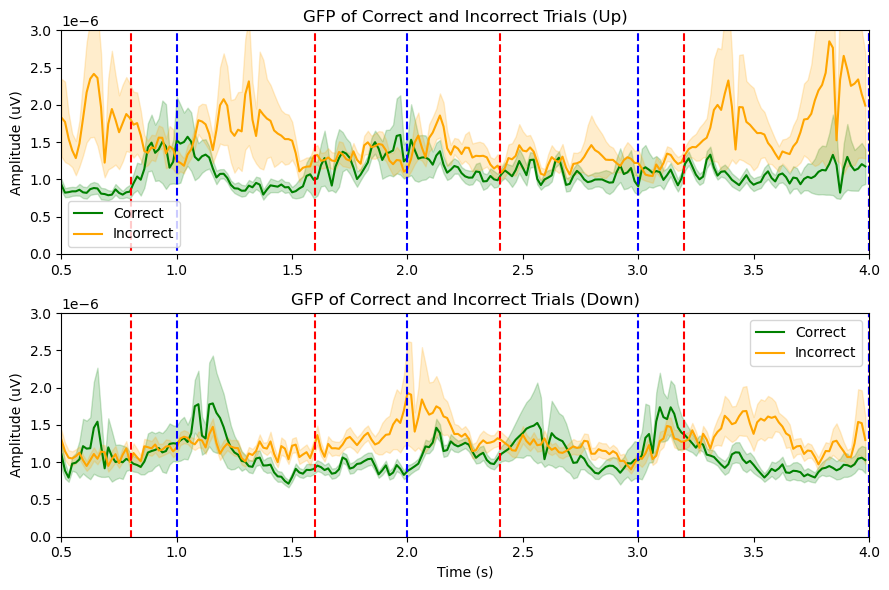

In [30]:
grouped = results_df_svc.groupby('sub_id')

# Iterate over each group
for i, (sub_id, group) in enumerate(grouped):
    correct_up_index = group.index[group['correct'] & (group['label'] == 0)].tolist()
    incorrect_up_index = group.index[~group['correct'] & (group['label'] == 0)].tolist()
    correct_down_index = group.index[group['correct'] & (group['label'] == 1)].tolist()
    incorrect_down_index = group.index[~group['correct'] & (group['label'] == 1)].tolist()

    gfp_correct_up = dataset[correct_up_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_incorrect_up = dataset[incorrect_up_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_correct_down = dataset[correct_down_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_incorrect_down = dataset[incorrect_down_index].get_eeg().mean(axis=0).std(axis=0)
    if i == 0:
        gfp_array = np.zeros((len(grouped), 4, len(gfp_correct_up)))
    gfp_array[i, 0] = gfp_correct_up
    gfp_array[i, 1] = gfp_incorrect_up
    gfp_array[i, 2] = gfp_correct_down
    gfp_array[i, 3] = gfp_incorrect_down

gfp_mean = gfp_array.mean(axis=0)
gfp_se = gfp_array.std(axis=0) / np.sqrt(len(grouped))

# Plot GFP
time = np.arange(0.5, 4, 1/64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

# Plot for 'up' label
ax1.plot(time, gfp_mean[0], color='green', label='Correct')
ax1.fill_between(time, gfp_mean[0] - gfp_se[0], gfp_mean[0] + gfp_se[0], color='green', alpha=0.2)
ax1.plot(time, gfp_mean[1], color='orange', label='Incorrect')
ax1.fill_between(time, gfp_mean[1] - gfp_se[1], gfp_mean[1] + gfp_se[1], color='orange', alpha=0.2)
ymin_up = np.min(gfp_mean[:2]) - np.max(gfp_se[:2])
ymax_up = np.max(gfp_mean[:2]) + np.max(gfp_se[:2])
ax1.vlines(np.linspace(0, 4, 6), ymin_up, 3e-6, color='r', linestyle='--')
ax1.vlines(np.linspace(0, 4, 5), ymin_up, 3e-6, color='b', linestyle='--')
ax1.set_xlim(0.5, 4)
ax1.set_ylim(0, 3e-6)
ax1.set_title('GFP of Correct and Incorrect Trials (Up)')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend()

# Plot for 'down' label
ax2.plot(time, gfp_mean[2], color='green', label='Correct')
ax2.fill_between(time, gfp_mean[2] - gfp_se[2], gfp_mean[2] + gfp_se[2], color='green', alpha=0.2)
ax2.plot(time, gfp_mean[3], color='orange', label='Incorrect')
ax2.fill_between(time, gfp_mean[3] - gfp_se[3], gfp_mean[3] + gfp_se[3], color='orange', alpha=0.2)
ymin_down = np.min(gfp_mean[2:]) - np.max(gfp_se[2:])
ymax_down = np.max(gfp_mean[2:]) + np.max(gfp_se[2:])
ax2.vlines(np.linspace(0, 4, 6), ymin_down, 3e-6, color='r', linestyle='--')
ax2.vlines(np.linspace(0, 4, 5), ymin_down, 3e-6, color='b', linestyle='--')
ax2.set_xlim(0.5, 4)
ax2.set_ylim(0, 3e-6)
ax2.set_title('GFP of Correct and Incorrect Trials (Down)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (uV)')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(path_dict['reports'], f"dataset-{dataset_name}_reports-eeg-waveform-correct-incorrect-subject-wise-gfp-subject-wise_model-svc.png"))

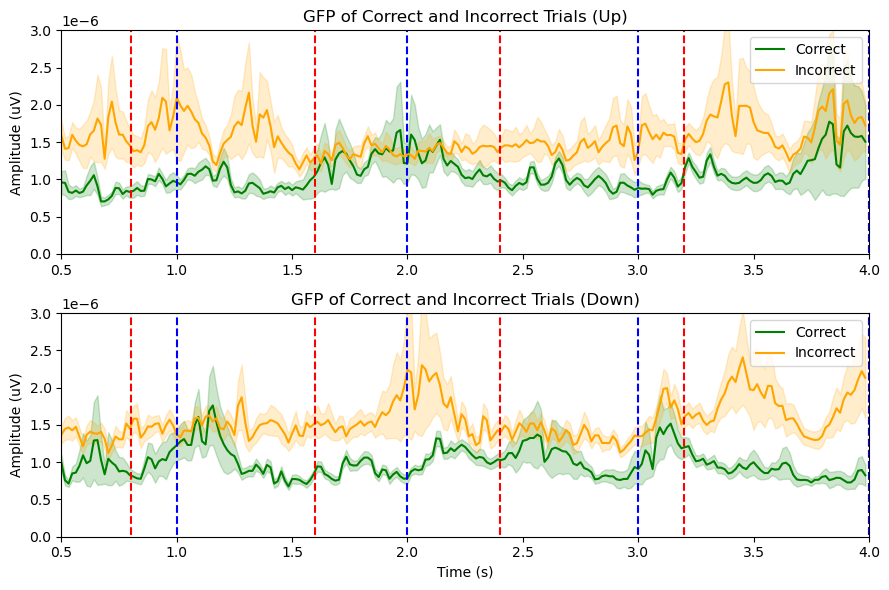

In [31]:
grouped = results_df_cnn.groupby('SubID')

# Iterate over each group
for i, (sub_id, group) in enumerate(grouped):
    correct_up_index = group.index[group['correct'] & (group['label'] == 0)].tolist()
    incorrect_up_index = group.index[~group['correct'] & (group['label'] == 0)].tolist()
    correct_down_index = group.index[group['correct'] & (group['label'] == 1)].tolist()
    incorrect_down_index = group.index[~group['correct'] & (group['label'] == 1)].tolist()

    gfp_correct_up = dataset[correct_up_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_incorrect_up = dataset[incorrect_up_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_correct_down = dataset[correct_down_index].get_eeg().mean(axis=0).std(axis=0)
    gfp_incorrect_down = dataset[incorrect_down_index].get_eeg().mean(axis=0).std(axis=0)
    if i == 0:
        gfp_array = np.zeros((len(grouped), 4, len(gfp_correct_up)))
    gfp_array[i, 0] = gfp_correct_up
    gfp_array[i, 1] = gfp_incorrect_up
    gfp_array[i, 2] = gfp_correct_down
    gfp_array[i, 3] = gfp_incorrect_down

gfp_mean = gfp_array.mean(axis=0)
gfp_se = gfp_array.std(axis=0) / np.sqrt(len(grouped))

# Plot GFP
time = np.arange(0.5, 4, 1/64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

# Plot for 'up' label
ax1.plot(time, gfp_mean[0], color='green', label='Correct')
ax1.fill_between(time, gfp_mean[0] - gfp_se[0], gfp_mean[0] + gfp_se[0], color='green', alpha=0.2)
ax1.plot(time, gfp_mean[1], color='orange', label='Incorrect')
ax1.fill_between(time, gfp_mean[1] - gfp_se[1], gfp_mean[1] + gfp_se[1], color='orange', alpha=0.2)
ymin_up = np.min(gfp_mean[:2]) - np.max(gfp_se[:2])
ymax_up = np.max(gfp_mean[:2]) + np.max(gfp_se[:2])
ax1.vlines(np.linspace(0, 4, 6), ymin_up, ymax_up, color='r', linestyle='--')
ax1.vlines(np.linspace(0, 4, 5), ymin_up, ymax_up, color='b', linestyle='--')
ax1.set_xlim(0.5, 4)
ax1.set_ylim(0, 3e-6)
ax1.set_title('GFP of Correct and Incorrect Trials (Up)')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend()

# Plot for 'down' label
ax2.plot(time, gfp_mean[2], color='green', label='Correct')
ax2.fill_between(time, gfp_mean[2] - gfp_se[2], gfp_mean[2] + gfp_se[2], color='green', alpha=0.2)
ax2.plot(time, gfp_mean[3], color='orange', label='Incorrect')
ax2.fill_between(time, gfp_mean[3] - gfp_se[3], gfp_mean[3] + gfp_se[3], color='orange', alpha=0.2)
ymin_down = np.min(gfp_mean[2:]) - np.max(gfp_se[2:])
ymax_down = np.max(gfp_mean[2:]) + np.max(gfp_se[2:])
ax2.vlines(np.linspace(0, 4, 6), ymin_down, ymax_down, color='r', linestyle='--')
ax2.vlines(np.linspace(0, 4, 5), ymin_down, ymax_down, color='b', linestyle='--')
ax2.set_xlim(0.5, 4)
ax2.set_ylim(0, 3e-6)
ax2.set_title('GFP of Correct and Incorrect Trials (Down)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (uV)')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(path_dict['reports'], f"dataset-{dataset_name}_reports-eeg-waveform-correct-incorrect-subject-wise-gfp_model-cnn.png"))